In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Cargar fuente de verdad
df = pd.read_csv('../../data/data.csv')

print(f"Dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Tasa de churn: {df['cancelacion'].mean():.2%}")

Dataset: 9701 filas x 64 columnas
Tasa de churn: 15.69%


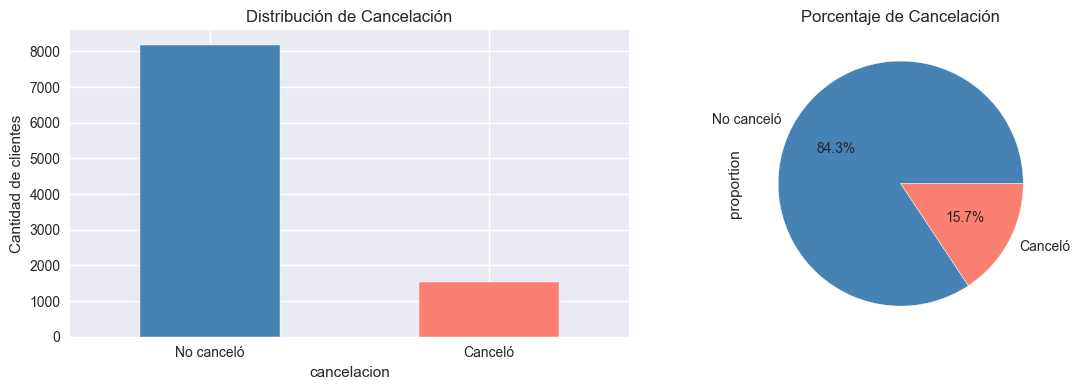

No canceló: 8,179 clientes
Canceló: 1,522 clientes


In [2]:
# Distribución de churn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1 - conteo
df['cancelacion'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'salmon']
)
axes[0].set_title('Distribución de Cancelación')
axes[0].set_xticklabels(['No canceló', 'Canceló'], rotation=0)
axes[0].set_ylabel('Cantidad de clientes')

# Gráfico 2 - porcentaje
df['cancelacion'].value_counts(normalize=True).plot(
    kind='pie', ax=axes[1],
    labels=['No canceló', 'Canceló'],
    autopct='%1.1f%%',
    colors=['steelblue', 'salmon']
)
axes[1].set_title('Porcentaje de Cancelación')

plt.tight_layout()
plt.savefig('../../outputs/01_distribucion_churn.png')
plt.show()
print(f"No canceló: {(df['cancelacion']==0).sum():,} clientes")
print(f"Canceló: {(df['cancelacion']==1).sum():,} clientes")

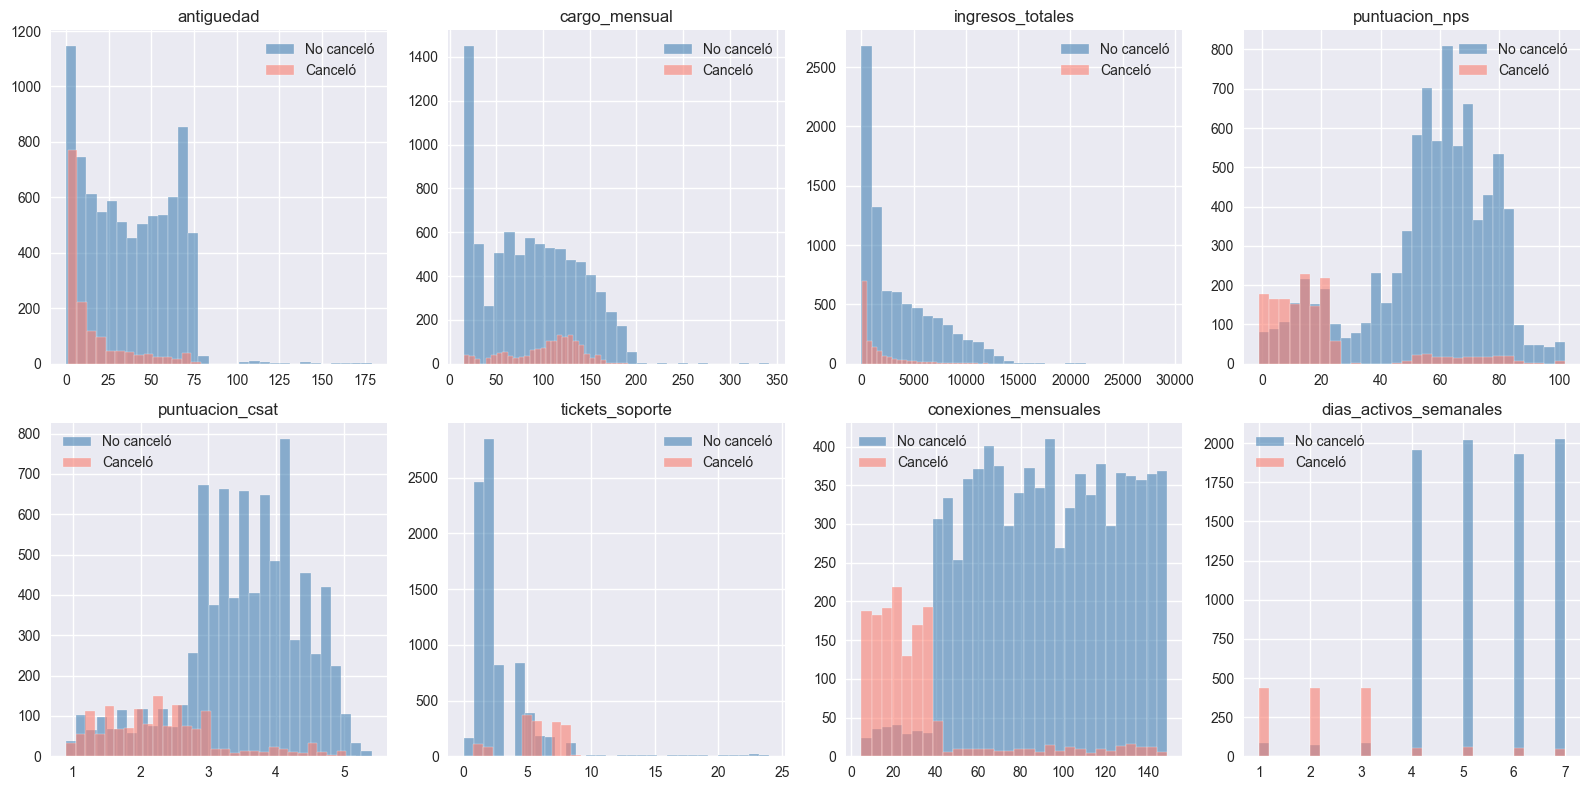

In [3]:
# Features numéricos más importantes para analizar
numericas = [
    'antiguedad', 'cargo_mensual', 'ingresos_totales',
    'puntuacion_nps', 'puntuacion_csat', 'tickets_soporte',
    'conexiones_mensuales', 'dias_activos_semanales'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    df[df['cancelacion']==0][col].hist(
        ax=axes[i], alpha=0.6, label='No canceló', color='steelblue', bins=30
    )
    df[df['cancelacion']==1][col].hist(
        ax=axes[i], alpha=0.6, label='Canceló', color='salmon', bins=30
    )
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.savefig('../../outputs/02_numericas_vs_churn.png')
plt.show()

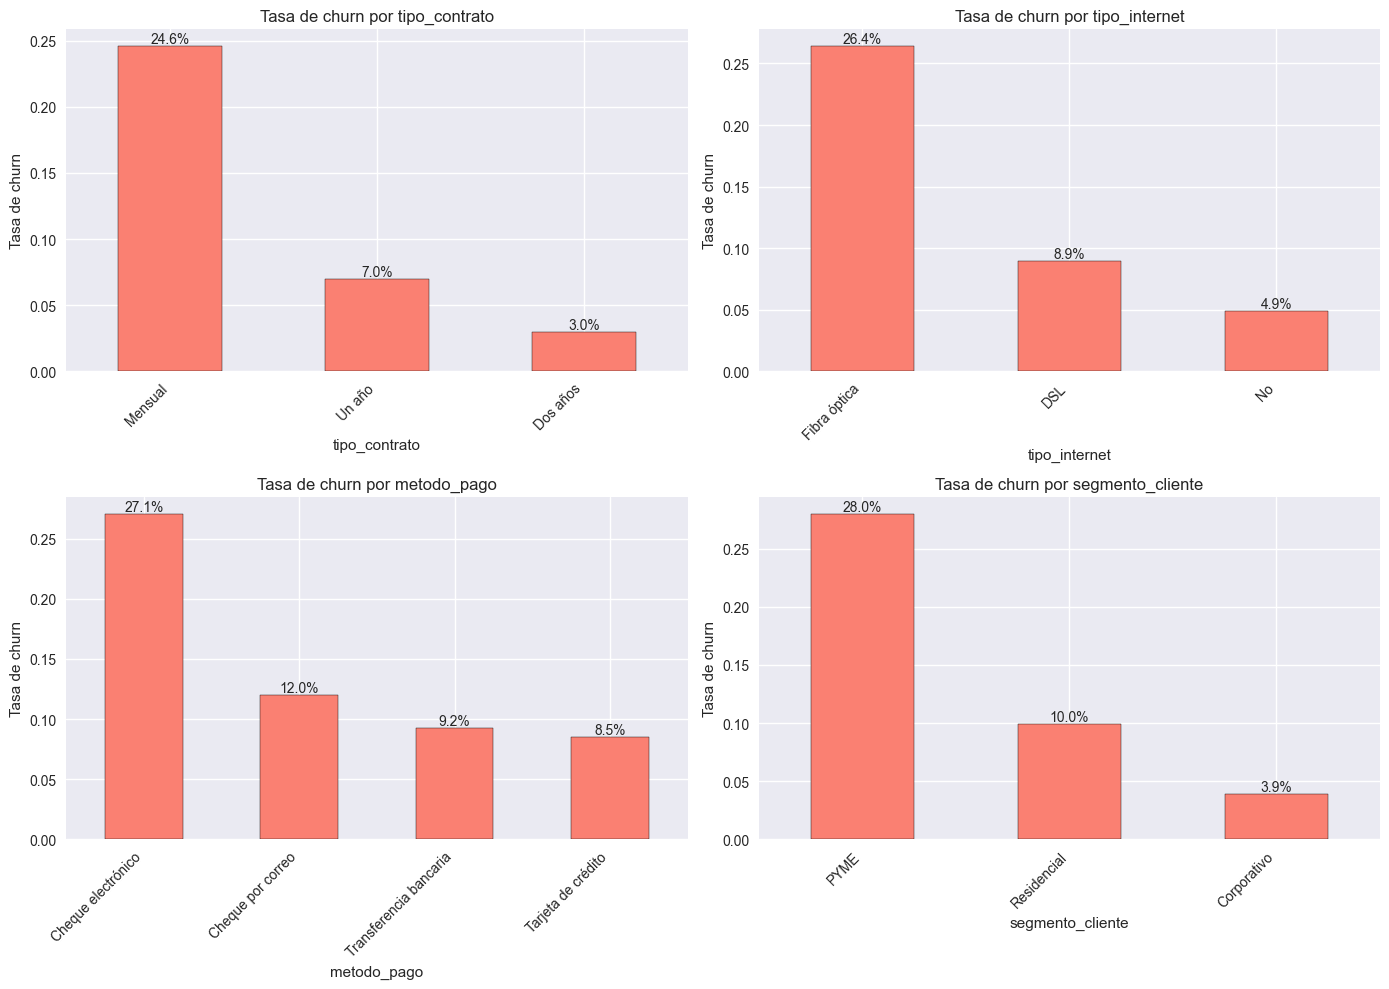

In [4]:
# Variables categóricas vs churn
categoricas = [
    'tipo_contrato', 'tipo_internet',
    'metodo_pago', 'segmento_cliente'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    churn_rate = df.groupby(col)['cancelacion'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i], color='salmon', edgecolor='black')
    axes[i].set_title(f'Tasa de churn por {col}')
    axes[i].set_ylabel('Tasa de churn')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.1%}',
                        (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../../outputs/03_categoricas_vs_churn.png')
plt.show()

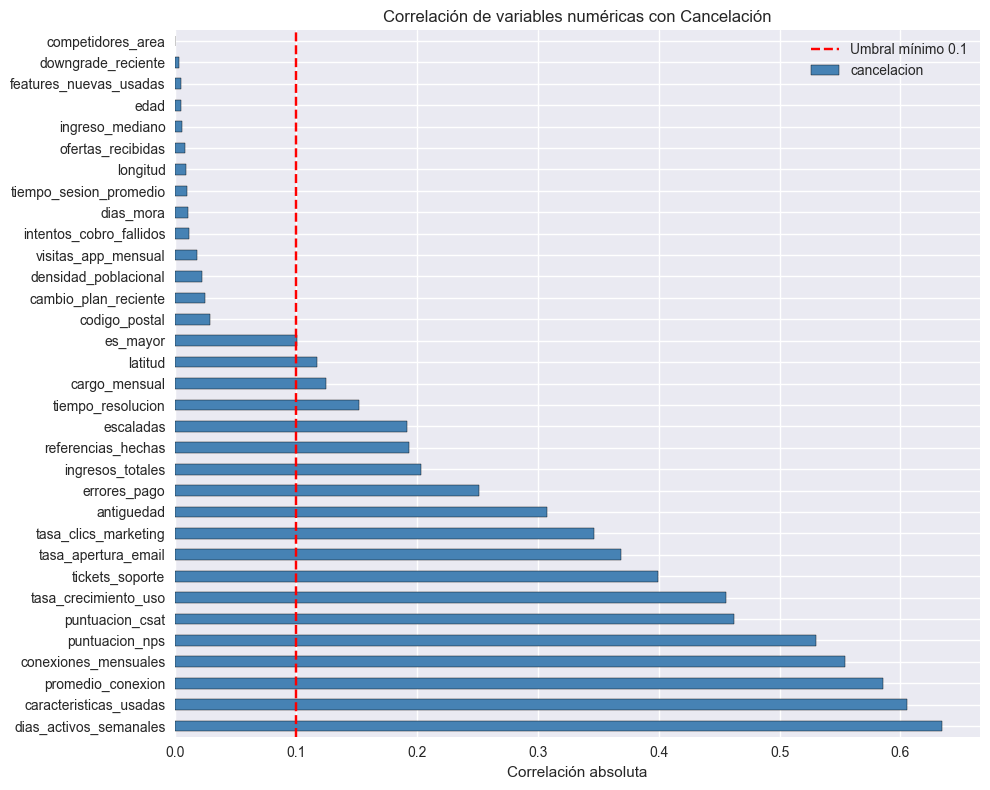

Top 10 variables más correlacionadas con cancelación:
dias_activos_semanales    0.634187
caracteristicas_usadas    0.605605
promedio_conexion         0.585281
conexiones_mensuales      0.553803
puntuacion_nps            0.530319
puntuacion_csat           0.462089
tasa_crecimiento_uso      0.455906
tickets_soporte           0.399844
tasa_apertura_email       0.369141
tasa_clics_marketing      0.346210


In [5]:
# Correlación de variables numéricas con cancelacion
numericas_todas = df.select_dtypes(include=[np.number]).columns.tolist()
correlaciones = df[numericas_todas].corr()['cancelacion'].drop('cancelacion')
correlaciones = correlaciones.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
correlaciones.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Correlación de variables numéricas con Cancelación')
plt.xlabel('Correlación absoluta')
plt.axvline(x=0.1, color='red', linestyle='--', label='Umbral mínimo 0.1')
plt.legend()
plt.tight_layout()
plt.savefig('../../outputs/04_correlaciones.png')
plt.show()

print("Top 10 variables más correlacionadas con cancelación:")
print(correlaciones.head(10).to_string())